<a href="https://colab.research.google.com/github/sanskrutimishra2307-droid/Machine_Vision_Lab/blob/main/MV_Prac_04_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Upload a metal surface image


Saving metal.png to metal.png


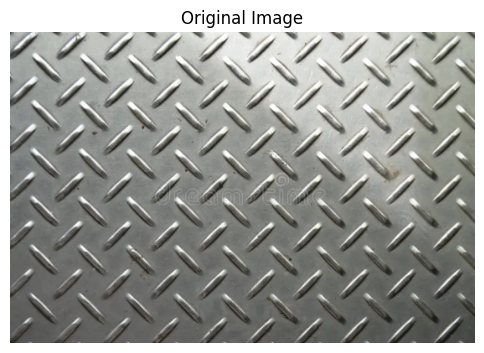

In [2]:
print("Upload a metal surface image")
uploaded = files.upload()

image_name = list(uploaded.keys())[0]

image = cv2.imread(image_name)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

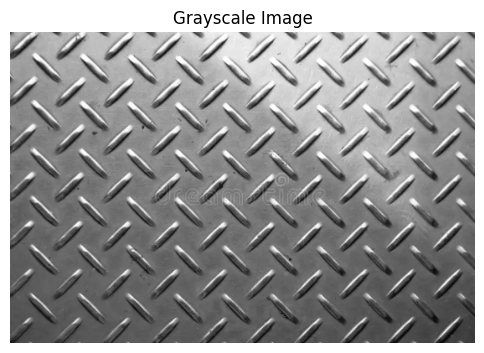

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

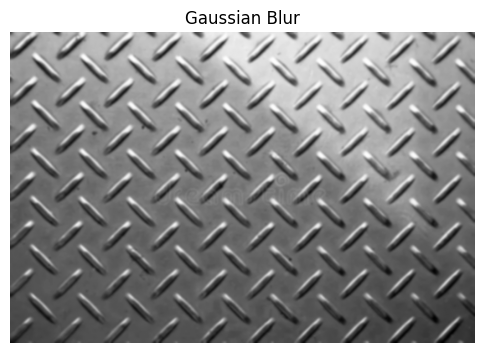

In [4]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.figure(figsize=(6,6))
plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

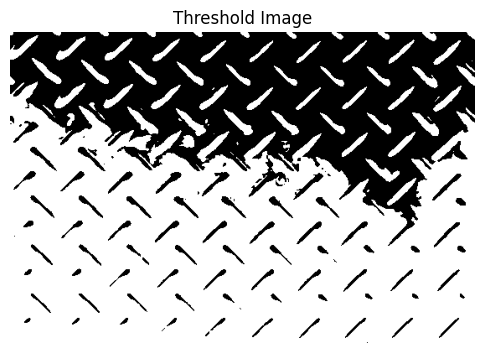

In [5]:
_, threshold = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(6,6))
plt.imshow(threshold, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

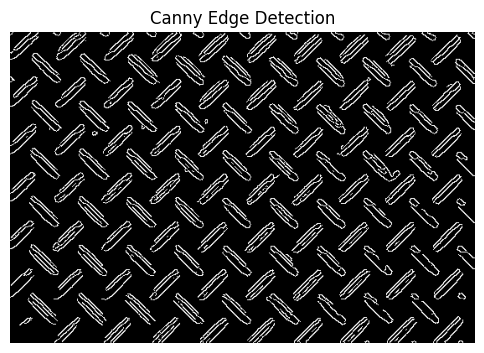

In [6]:
edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

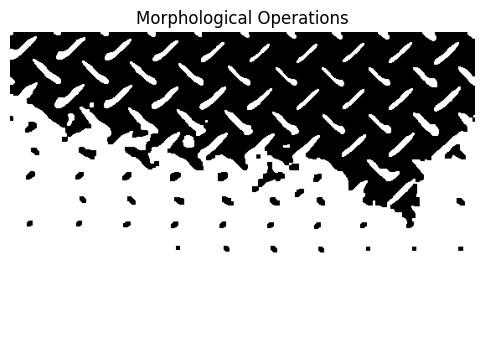

In [7]:
kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(
    threshold,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

closing = cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

plt.figure(figsize=(6,6))
plt.imshow(closing, cmap='gray')
plt.title("Morphological Operations")
plt.axis("off")
plt.show()

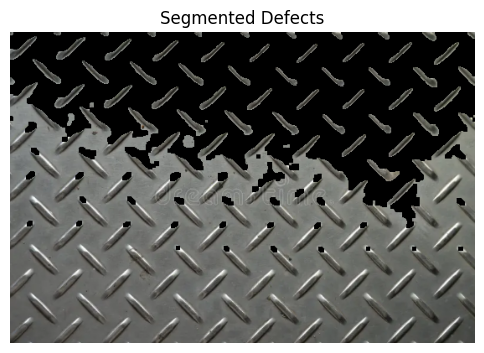

In [8]:
segmented = cv2.bitwise_and(image_rgb, image_rgb, mask=closing)

plt.figure(figsize=(6,6))
plt.imshow(segmented)
plt.title("Segmented Defects")
plt.axis("off")
plt.show()

In [9]:
contours, _ = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of Contours Found:", len(contours))

Number of Contours Found: 57


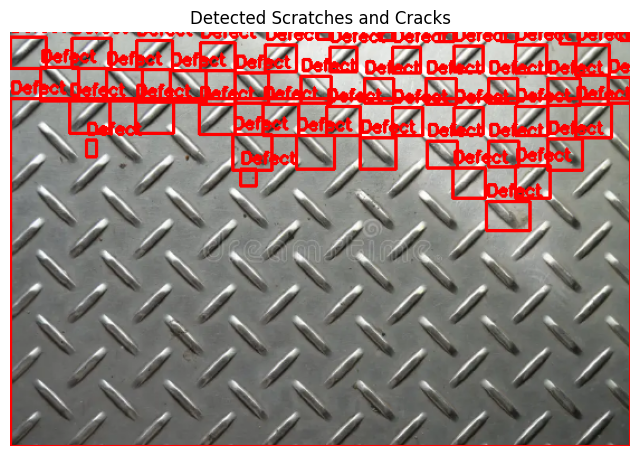

Total Defects Detected: 47


In [10]:
result = image_rgb.copy()

count = 0

for contour in contours:

    area = cv2.contourArea(contour)

    if area > 40:

        count += 1

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(result, (x,y), (x+w,y+h), (255,0,0), 2)

        cv2.putText(
            result,
            "Defect",
            (x,y-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255,0,0),
            2
        )

plt.figure(figsize=(8,8))
plt.imshow(result)
plt.title("Detected Scratches and Cracks")
plt.axis("off")
plt.show()

print("Total Defects Detected:", count)